In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
wine = load_wine()
data = pd.DataFrame(data=np.c_[wine.data, wine['target']], columns=wine.feature_names + ['target'])
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0.0


In [3]:
X = data.drop('target', axis=1)
# X = data.iloc[:, :-1] # Alternativa para seleccionar todas las columnas excepto la última
y = data['target']
# y = data.iloc[:, -1] # Alternativa para seleccionar solo la última columna

In [4]:
# Dividir los datos en conjunto de entrenamiento y prueba
# Reservo el 20% de los datos para pruebas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Vamos a escalar los datos
from sklearn.preprocessing import StandardScaler # Importa la clase para estandarizar características
scaler = StandardScaler() # Crea una instancia del escalador
X_train = scaler.fit_transform(X_train) # Ajusta el escalador a los datos de entrenamiento y transforma los datos
X_test = scaler.transform(X_test) # Transforma los datos de prueba usando el mismo escalador

In [8]:
param_grid = { # Definimos los hiperparámetros a ajustar
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3, cv=5) # Configuramos la búsqueda en cuadrícula con validación cruzada. Refit=True significa que se ajustará el mejor modelo encontrado con todos los datos de entrenamiento. Verbose=2 proporciona detalles del proceso.
grid.fit(X_train, y_train) # Ajustamos el modelo a los datos de entrenamiento
print("Mejores hiperparámetros encontrados: ", grid.best_params_) # Imprimimos los mejores hiperparámetros encontrados

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.414 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.414 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.393 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.393 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.393 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.966 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.966 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.964 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.964 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=1, kernel=linear;, score=1.000 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.931 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf

In [9]:
y_pred = grid.predict(X_test) # Hacemos predicciones con el modelo ajustado
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred)) # Imprimimos la matriz de confusión
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred)) # Imprimimos el reporte de clasificación
print("Precisión del modelo: ", accuracy_score(y_test, y_pred)) # Imprimimos la precisión del modelo

Matriz de confusión:
 [[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

Reporte de clasificación:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        14
         1.0       1.00      1.00      1.00        14
         2.0       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Precisión del modelo:  1.0


## Visualización de las fronteras de decisión (opcional)

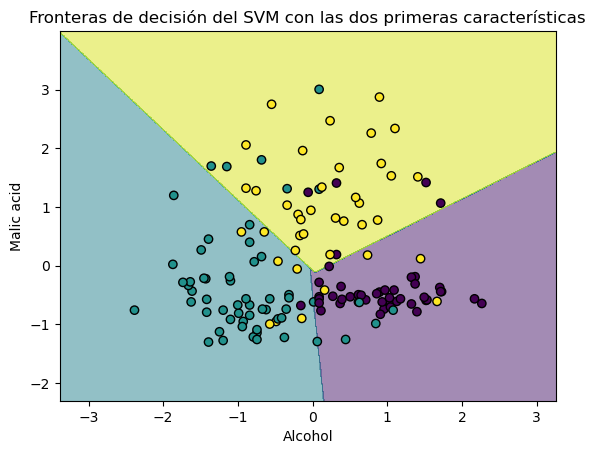

In [10]:
X_reducido = X_train[:, :2]  # Usamos solo las dos primeras características para la visualización
Y_reducido = y_train  # Usamos todas las etiquetas correspondientes

svm_reducido = SVC(C=grid.best_params_['C'], gamma=grid.best_params_['gamma'], kernel='linear')
svm_reducido.fit(X_reducido, Y_reducido) # Ajustamos el modelo SVM con las mejores hiperparámetros encontrados el modelo reducido

# Crear una malla para graficar las fronteras de decisión
x_min, x_max = X_reducido[:, 0].min() - 1, X_reducido[:, 0].max() + 1
y_min, y_max = X_reducido[:, 1].min() - 1, X_reducido[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
Z = svm_reducido.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.5)
plt.scatter(X_reducido[:, 0], X_reducido[:, 1], c=Y_reducido, edgecolors='k', marker='o')
plt.title('Fronteras de decisión del SVM con las dos primeras características')
plt.xlabel('Alcohol')
plt.ylabel('Malic acid')
plt.show()